**套件安裝**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install torch torchvision scikit-learn

**引入套件**

In [3]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

**基本設定**

In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda")
print("Using device:", device)

Using device: cuda


**路徑與超參數**

In [27]:
# 資料夾結構假設：
# ./Rock Paper Scissors Dataset/train/paper|rock|scissors
# ./Rock Paper Scissors Dataset/validation/paper|rock|scissors
# ./Rock Paper Scissors Dataset/test/paper|rock|scissors

# 將資料集路徑調整為 Google Drive 上的路徑
data_root = "/content/drive/MyDrive/Rock Paper Scissors Dataset"

train_dir = os.path.join(data_root, "train")
val_dir   = os.path.join(data_root, "validation")
test_dir  = os.path.join(data_root, "test")

# 原圖大小為 300x300，不做任何縮放
image_size    = 300
batch_size    = 4
num_epochs    = 10
learning_rate = 1e-3
weight_decay  = 1e-4
step_size     = 5    # LR scheduler 每幾個 epoch 衰減一次
gamma         = 0.1  # 衰減倍率

print("Train dir:", train_dir)
print("Val dir:", val_dir)
print("Test dir:", test_dir)

Train dir: /content/drive/MyDrive/Rock Paper Scissors Dataset/train
Val dir: /content/drive/MyDrive/Rock Paper Scissors Dataset/validation
Test dir: /content/drive/MyDrive/Rock Paper Scissors Dataset/test


**資料前處理與增強**

In [28]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# 訓練集：確保 H,W 為 image_size，並進行旋轉/翻轉/顏色/仿射等增強
train_transform = transforms.Compose([
    transforms.Resize(image_size),             # 將較短邊縮放到 image_size
    transforms.RandomCrop(image_size),         # 從隨機位置裁剪 image_size x image_size 的區域
    transforms.RandomHorizontalFlip(p=0.5),        # 左右翻轉
    transforms.RandomRotation(degrees=20),         # 旋轉
    transforms.ColorJitter(                        # 亮度 / 對比 / 飽和 / 色調
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.02
    ),
    transforms.RandomAffine(                       # 輕微平移 / shear，scale=1 不縮放
        degrees=0,
        translate=(0.05, 0.05),
        scale=None,          # 不設定縮放，等同於 scale=1
        shear=5
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# 驗證 / 測試集：確保 H,W 為 image_size，只做 ToTensor + Normalize
eval_transform = transforms.Compose([
    transforms.Resize(image_size),             # 將較短邊縮放到 image_size
    transforms.CenterCrop(image_size),         # 從中心裁剪 image_size x image_size 的區域
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

**建立 Dataset / DataLoader**

In [29]:
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(root=val_dir,   transform=eval_transform)
test_dataset  = datasets.ImageFolder(root=test_dir,  transform=eval_transform)

class_names = train_dataset.classes
num_classes = len(class_names)
print("Classes:", class_names)

train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True,
    num_workers=0, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False,
    num_workers=0, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False,
    num_workers=0, pin_memory=True
)

Classes: ['paper', 'rock', 'scissors']


**模型架構**

In [30]:
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

# 先凍結所有參數
for p in model.parameters():
    p.requires_grad = False

# 只開最後一個 block (layer4) + fc
for p in model.layer4.parameters():
    p.requires_grad = True

in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)  # 3 類：paper / rock / scissors

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=learning_rate,
    weight_decay=weight_decay
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=step_size,
    gamma=gamma
)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

**訓練與驗證函式**

In [31]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        _, preds = torch.max(outputs, dim=1)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = running_corrects.double().item() / len(dataloader.dataset)
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_corrects = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, dim=1)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = running_corrects.double().item() / len(dataloader.dataset)
    return epoch_loss, epoch_acc


**訓練**

In [32]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_acc = 0.0
best_model_state = None

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_acc": val_acc,
        }

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  "
          f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}")

print("Best Val Acc:", best_val_acc)

# 載入最佳驗證成績的權重
if best_model_state is not None:
    model.load_state_dict(best_model_state["model_state_dict"])

Epoch [1/10] Train Loss: 0.2476  Train Acc: 0.9254  Val Loss: 0.3327  Val Acc: 0.8788
Epoch [2/10] Train Loss: 0.0899  Train Acc: 0.9754  Val Loss: 1.4990  Val Acc: 0.6667
Epoch [3/10] Train Loss: 0.0571  Train Acc: 0.9869  Val Loss: 0.2263  Val Acc: 0.9394
Epoch [4/10] Train Loss: 0.0368  Train Acc: 0.9893  Val Loss: 0.0779  Val Acc: 1.0000
Epoch [5/10] Train Loss: 0.0824  Train Acc: 0.9774  Val Loss: 0.0361  Val Acc: 1.0000
Epoch [6/10] Train Loss: 0.0053  Train Acc: 0.9992  Val Loss: 0.0425  Val Acc: 1.0000
Epoch [7/10] Train Loss: 0.0083  Train Acc: 0.9984  Val Loss: 0.0240  Val Acc: 1.0000
Epoch [8/10] Train Loss: 0.0031  Train Acc: 0.9996  Val Loss: 0.0626  Val Acc: 0.9697
Epoch [9/10] Train Loss: 0.0020  Train Acc: 1.0000  Val Loss: 0.0252  Val Acc: 1.0000
Epoch [10/10] Train Loss: 0.0014  Train Acc: 1.0000  Val Loss: 0.0508  Val Acc: 0.9697
Best Val Acc: 1.0


**畫訓練曲線 (Loss / Accuracy)**

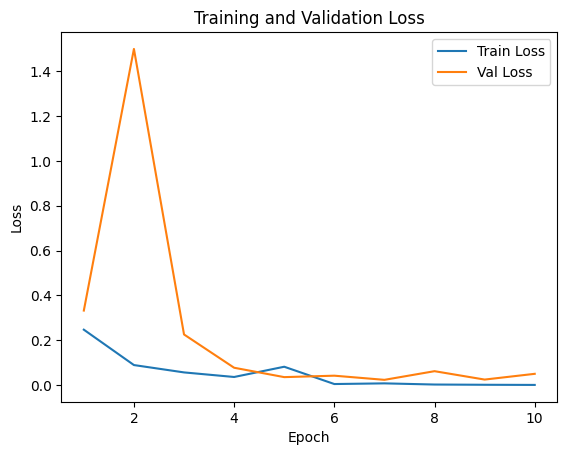

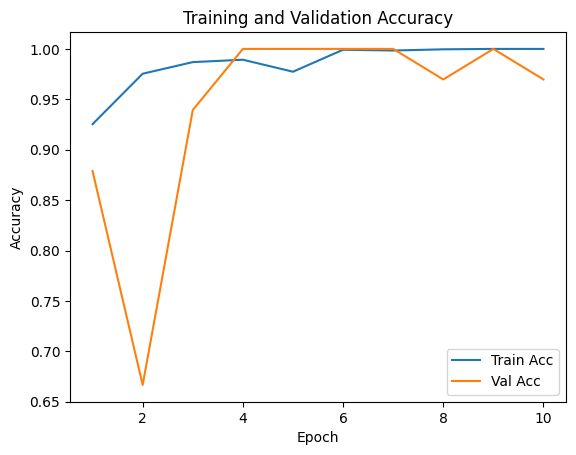

In [33]:
epochs_range = range(1, num_epochs + 1)

plt.figure()
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs_range, train_accs, label="Train Acc")
plt.plot(epochs_range, val_accs, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

**測試集評估**

In [34]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}  Test Acc: {test_acc:.4f}")

Test Loss: 0.0046  Test Acc: 1.0000


**混淆矩陣**

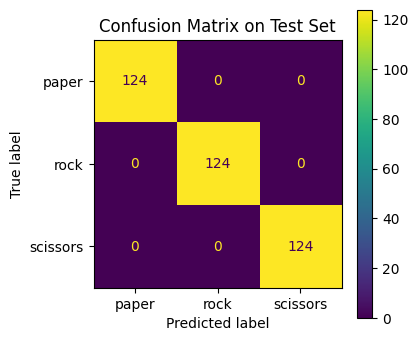

In [35]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=class_names)

fig, ax = plt.subplots(figsize=(4, 4))
disp.plot(ax=ax, values_format="d")
plt.title("Confusion Matrix on Test Set")
plt.show()